# 3. EDA and Statistical Analysis

Describe coverage, financial ratios, outcome-year pressure rates and sector differences using the supplied processed panel. All unknown next-year labels are excluded from pressure-rate denominators.

Ratio clipping uses only the 2014–2018 training subset's 1st/99th percentiles. It supports readable descriptive comparisons; raw medians are used for Tableau. Statistical comparisons across the full panel are retrospective and do not select model settings.

In [1]:
from pathlib import Path
import sys

# Works from the project root or any folder beneath it.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebooks/analysis_helpers.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Start Jupyter inside the project folder.")
if str(ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(ROOT / "notebooks"))

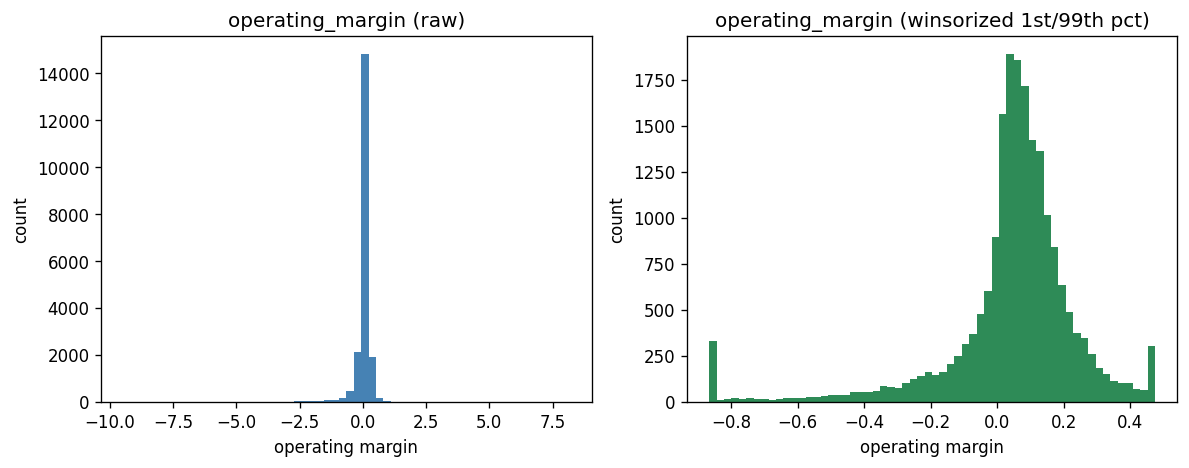

=== Structure ===
companies: 2767 | rows: 21990
                                     n_companies  n_rows
sector                                                  
Consumer / Retail                            426    3524
Energy / Capital-intensive                   353    2647
Industrial / Manufacturing                  1040    8628
Technology / Software / Electronics          979    7191

Size skew (log_assets):
count    21990.00
mean        21.37
std          1.68
min         17.03
25%         20.14
50%         21.29
75%         22.48
max         27.25

=== Financial performance by sector ===
                                     operating_margin  liabilities_to_assets  operating_cash_flow_to_assets
sector                                                                                                     
Consumer / Retail                               0.042                  0.625                          0.088
Energy / Capital-intensive                      0.144                  0.586

In [2]:
"""EDA and statistical analysis."""
import os

import numpy as np
import pandas as pd
import scipy.stats as st

BASE = ROOT
PROC = os.path.join(BASE, "data", "processed")


RATIO_COLS = ["operating_margin", "net_margin", "operating_cash_flow_to_assets",
              "cash_to_assets", "liabilities_to_assets", "current_ratio",
              "asset_turnover", "capex_to_revenue", "revenue_growth",
              "change_in_revenue_growth", "change_in_operating_margin",
              "three_year_operating_margin_volatility"]


def winsorize(df):
    """Clip ratio features at the 1st/99th percentile to tame tiny-shell outliers."""
    df = df.copy()
    for c in RATIO_COLS:
        if c in df.columns:
            train = df.loc[df.fiscal_year.between(2014, 2018) & df.next_year_financial_pressure.notna(), c]
            lo, hi = train.quantile(0.01), train.quantile(0.99)
            df[c] = df[c].clip(lo, hi)
    return df


def main():
    raw = pd.read_csv(os.path.join(PROC, "company_year_panel.csv"), dtype={"cik": str})
    df = winsorize(raw)

    # before/after distribution for a representative ratio
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(raw["operating_margin"].dropna(), bins=60, color="steelblue")
    axes[0].set_title("operating_margin (raw)")
    axes[1].hist(df["operating_margin"].dropna(), bins=60, color="seagreen")
    axes[1].set_title("operating_margin (winsorized 1st/99th pct)")
    for ax in axes:
        ax.set_xlabel("operating margin")
        ax.set_ylabel("count")
    plt.tight_layout()
    from io import BytesIO
    from IPython.display import Image, display
    image_buffer = BytesIO()
    fig.savefig(image_buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=image_buffer.getvalue()))
    plt.close(fig)

    print("=== Structure ===")
    print("companies:", df["cik"].nunique(), "| rows:", len(df))
    print(df.groupby("sector").agg(n_companies=("cik", "nunique"),
                                   n_rows=("cik", "size")).to_string())
    print("\nSize skew (log_assets):")
    print(df["log_assets"].describe().round(2).to_string())

    print("\n=== Financial performance by sector ===")
    print(df.groupby("sector")[["operating_margin", "liabilities_to_assets",
                                "operating_cash_flow_to_assets"]].median().round(3).to_string())

    print("\n=== Revenue growth vs OCF correlation ===")
    print("corr(revenue_growth, ocf_to_assets):",
          round(df[["revenue_growth", "operating_cash_flow_to_assets"]].corr().iloc[0, 1], 3))

    print("\n=== Correlation matrix (main continuous features) ===")
    corr_cols = ["operating_margin", "operating_cash_flow_to_assets",
                 "liabilities_to_assets", "revenue_growth", "log_assets", "current_ratio"]
    print(df[corr_cols].corr().round(2).to_string())

    print("\n=== Label ===")
    p = df["next_year_financial_pressure"].dropna()  # exclude unknown labels
    print("overall pressure rate:", round(p.mean() * 100, 2), "%")
    ci = st.t.interval(0.95, df=len(p) - 1, loc=p.mean(), scale=p.std(ddof=1) / np.sqrt(len(p)))
    print("Approximate 95% row-level interval for pressure rate:", round(ci[0] * 100, 2), "-", round(ci[1] * 100, 2), "%")
    print("\npressure rate by outcome year (label refers to the NEXT fiscal year):")
    by_year = df.dropna(subset=["next_year_financial_pressure"]).groupby("fiscal_year")["next_year_financial_pressure"].mean() * 100
    by_year.index = by_year.index + 1
    by_year.index.name = "outcome_year"
    print(by_year.round(1).to_string())

    print("\n=== Two-group comparison (future pressure vs not, current-year) ===")
    for feat in ["operating_margin", "operating_cash_flow_to_assets", "liabilities_to_assets"]:
        a = df[df["next_year_financial_pressure"] == 1][feat].dropna()
        b = df[df["next_year_financial_pressure"] == 0][feat].dropna()
        t, pv = st.ttest_ind(a, b, equal_var=False)
        d = (a.mean() - b.mean()) / np.sqrt((a.std() ** 2 + b.std() ** 2) / 2)
        print(f"  {feat}: mean_diff={a.mean()-b.mean():.4f}, t={t:.2f}, p={pv:.3g}, "
              f"standardized_difference={d:.3f}")

    print("\n=== Peer percentiles (sector-year ranking) ===")
    peer = df.copy()
    for feat in ["operating_margin", "operating_cash_flow_to_assets", "liabilities_to_assets"]:
        peer[feat + "_pct"] = peer.groupby(["sector", "fiscal_year"])[feat].rank(pct=True)
    print(peer.dropna(subset=["operating_margin_pct"])[["sector", "fiscal_year", "operating_margin", "operating_margin_pct"]].head(5).round(3).to_string(index=False))
    print("(percentile within each sector-year, so capital-intensive vs asset-light firms are not compared on the same absolute scale)")

    print("\n=== Chi-square: sector vs pressure ===")
    ct = pd.crosstab(df["sector"], df["next_year_financial_pressure"])
    chi2, pv, dof, _ = st.chi2_contingency(ct)
    print(f"chi2={chi2:.2f}, p={pv:.3g}, dof={dof}")


main()

## Interpretation

The displayed two-group comparisons describe associations. The standardized difference divides the mean difference by the square root of the average of the two variances; it is not a causal effect. Repeated company observations and common year shocks violate independence assumptions, so the simple row-level interval and test p-values are descriptive approximations, not firm-clustered inference.

Operating margin and cash flow help explain historical pressure patterns. Leverage should be read with sector peers. Model coefficients and their conditional interpretation are in [Notebook 04](04_risk_modeling.ipynb).